## **Project Name: "Customer Churn Prediction"** ##

### **Setup & Load Data** ###

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.optimizers import Adam
base_path = "/content/drive/MyDrive/Internship Projects DS/Telecom Customer Churn Prediction Dataset/"

df = pd.read_csv(base_path + "telecom_customer_churn.csv")
zipcode_df = pd.read_csv(base_path + "telecom_zipcode_population.csv")

df.head()



Mounted at /content/drive


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


### **Data Preprocessing** ###

In [2]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

base_path = "/content/drive/MyDrive/Internship Projects DS/Telecom Customer Churn Prediction Dataset/"
df = pd.read_csv(base_path + "telecom_customer_churn.csv")
df.columns = df.columns.str.strip()

print("Available Columns:\n", df.columns.tolist())
possible_churn_cols = [
    'Churn', 'churn', 'Churn Label', 'Customer Status',
    'Exited', 'Churn_Value', 'Churn_Yes_No'
]

churn_col = None
for col in possible_churn_cols:
    if col in df.columns:
        churn_col = col
        break

if churn_col is None:
    raise ValueError(" Churn column not found in dataset")

print(f"Using target column: {churn_col}")


id_cols = ['customerID', 'CustomerID', 'customer_id']
df.drop(columns=[c for c in id_cols if c in df.columns], inplace=True)


if df[churn_col].dtype == 'object':
    df[churn_col] = df[churn_col].map({
        'Yes': 1, 'No': 0,
        'Churned': 1, 'Stayed': 0
    })

df.rename(columns={churn_col: 'Churn'}, inplace=True)

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


df.fillna(df.median(numeric_only=True), inplace=True)

categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("\nDATA PREPROCESSING COMPLETED SUCCESSFULLY")
print("Train Shape:", X_train_scaled.shape)
print("Test Shape:", X_test_scaled.shape)
print("Churn Distribution:\n", y.value_counts())


Available Columns:
 ['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason']
Using target column: Customer Status

DATA PREPROCESSING COMPLETED SUCCESSFULLY
Train Shape: (5634, 8209)
Test Shape: (1409, 8209)
Churn Distribution:
 Churn
0.0    5174
1.0    1869
Name: count, dtype: int64


### **REMOVE LEAKAGE** ###

In [3]:
leakage_cols = [
    'Customer Status',
    'Churn Category',
    'Churn Reason'
]

df.drop(columns=[col for col in leakage_cols if col in df.columns], inplace=True)

print("Leakage columns removed")
print("Remaining shape:", df.shape)


Leakage columns removed
Remaining shape: (7043, 8210)


### **DROP HIGH-CARDINALITY COLUMNS** ###

In [4]:
high_cardinality_cols = [
    'City',
    'Zip Code'
]

df.drop(columns=[col for col in high_cardinality_cols if col in df.columns], inplace=True)

print("High-cardinality columns removed")
print("New shape:", df.shape)


High-cardinality columns removed
New shape: (7043, 8209)


### **FINAL ENCODING + SPLIT + SCALING (CLEAN PIPELINE)** ###

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Final data ready for modeling")
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


 Final data ready for modeling
Train shape: (5634, 8208)
Test shape: (1409, 8208)


## **Build the ANN Baseline Model** ##

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,050,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,059,073 (4.04 MB)

 Trainable params: 1,059,073 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.7095 - loss: 0.5722 - val_accuracy: 0.9299 - val_loss: 0.2107
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9762 - loss: 0.0704 - val_accuracy: 0.9290 - val_loss: 0.1747
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9992 - loss: 0.0045 - val_accuracy: 0.9281 - val_loss: 0.1759
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9255 - val_loss: 0.1820
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9237 - val_loss: 0.1862
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 5.7616e-04 - val_accuracy: 0.9246 - val_loss: 0.1912
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9995 - loss: 8.2507e-04 - val_accuracy: 0.9219 - val_loss: 0.1982
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 3.4051e-

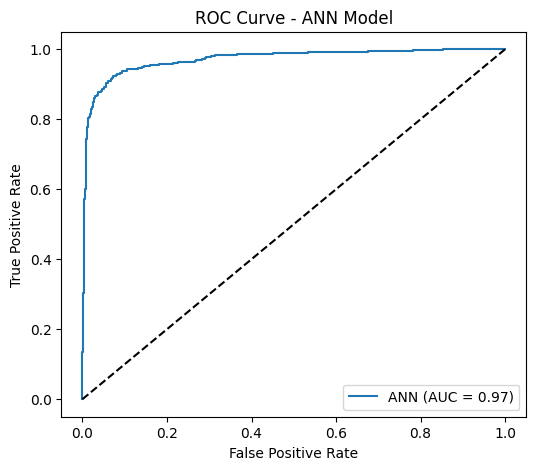

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()
history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_prob = ann_model.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)


ann_accuracy = accuracy_score(y_test, y_pred)
ann_precision = precision_score(y_test, y_pred)
ann_recall = recall_score(y_test, y_pred)
ann_f1 = f1_score(y_test, y_pred)

print("ANN Model Performance")
print("Accuracy :", ann_accuracy)
print("Precision:", ann_precision)
print("Recall   :", ann_recall)
print("F1 Score :", ann_f1)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ANN Model')
plt.legend()
plt.show()





## **LSTM MODEL** ##

### **Build LSTM Model** ###

LSTM Train Shape: (5634, 1, 8208)
LSTM Test Shape: (1409, 1, 8208)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │     2,117,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,953 (8.08 MB)

 Trainable params: 2,117,953 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.5230 - loss: 0.7937 - val_accuracy: 0.3407 - val_loss: 1.0103
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5736 - loss: 0.6632 - val_accuracy: 0.2724 - val_loss: 0.9445
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9129 - loss: 0.4554 - val_accuracy: 0.2972 - val_loss: 0.9252
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9859 - loss: 0.1863 - val_accuracy: 0.2999 - val_loss: 0.9925
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9984 - loss: 0.0681 - val_accuracy: 0.2946 - val_loss: 1.0849
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9999 - loss: 0.0304 - val_accuracy: 0.2937 - val_loss: 1.1490
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 1.0000 - loss: 0.0170 - val_accuracy: 0.2910 - val_loss: 1.1905
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 1.0000 - loss: 0.0111 - val_accu

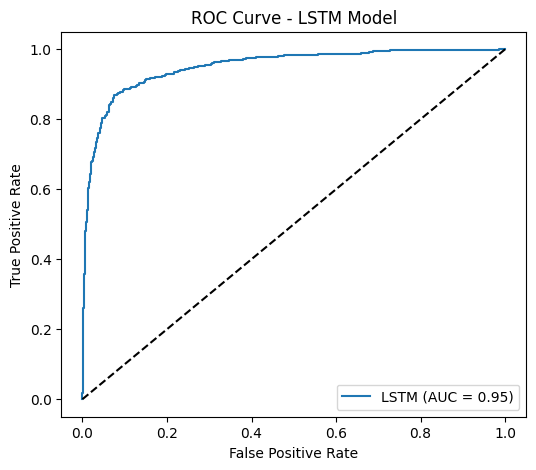

In [7]:


X_train_lstm = X_train_scaled.reshape(
    (X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
)

X_test_lstm = X_test_scaled.reshape(
    (X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
)

print("LSTM Train Shape:", X_train_lstm.shape)
print("LSTM Test Shape:", X_test_lstm.shape)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

lstm_model = Sequential([
    LSTM(64, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()
lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt


y_pred_prob_lstm = lstm_model.predict(X_test_lstm).ravel()
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)


lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
lstm_precision = precision_score(y_test, y_pred_lstm)
lstm_recall = recall_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

print("LSTM Model Performance")
print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_lstm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'LSTM (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM Model')
plt.legend()
plt.show()





## **AUTOENCODER** ##

Autoencoder training data shape: (4139, 8208)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8208)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,050,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8208)           │     1,058,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,130,352 (8.13 MB)

 Trainable params: 2,130,352 (8.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.8266 - val_loss: 0.8309
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.8305 - val_loss: 0.8309
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.8281 - val_loss: 0.8304
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.8279 - val_loss: 0.8303
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.8235 - val_loss: 0.8303
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.8243 - val_loss: 0.8304
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.8190 - val_loss: 0.8303
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.8176 - val_loss: 0.8303
Epoch 9/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.8124 - val_loss: 0.8303
Epoch 10/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.8130 - val_loss: 0.8303
Epoch 11/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.8085 - val_loss: 0.8303
Epoch 12/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 

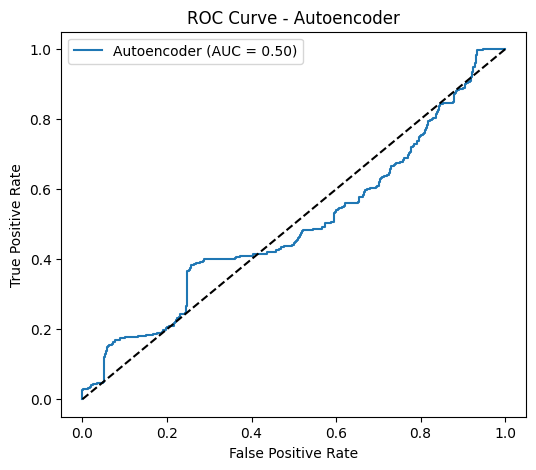

In [8]:
import numpy as np
X_train_ae = X_train_scaled[y_train == 0]

print("Autoencoder training data shape:", X_train_ae.shape)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()
history_ae = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

reconstructions = autoencoder.predict(X_test_scaled)


reconstruction_error = np.mean(
    np.square(X_test_scaled - reconstructions),
    axis=1
)


threshold = np.percentile(reconstruction_error, 95)

print("Reconstruction error threshold:", threshold)

y_pred_ae = (reconstruction_error > threshold).astype(int)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

ae_accuracy = accuracy_score(y_test, y_pred_ae)
ae_precision = precision_score(y_test, y_pred_ae)
ae_recall = recall_score(y_test, y_pred_ae)
ae_f1 = f1_score(y_test, y_pred_ae)

print("Autoencoder Performance")
print("Accuracy :", ae_accuracy)
print("Precision:", ae_precision)
print("Recall   :", ae_recall)
print("F1 Score :", ae_f1)

ae_scores = reconstruction_error / reconstruction_error.max()

fpr, tpr, _ = roc_curve(y_test, ae_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Autoencoder (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Autoencoder')
plt.legend()
plt.show()



### **MODEL COMPARISON + DASHBOARD** ###

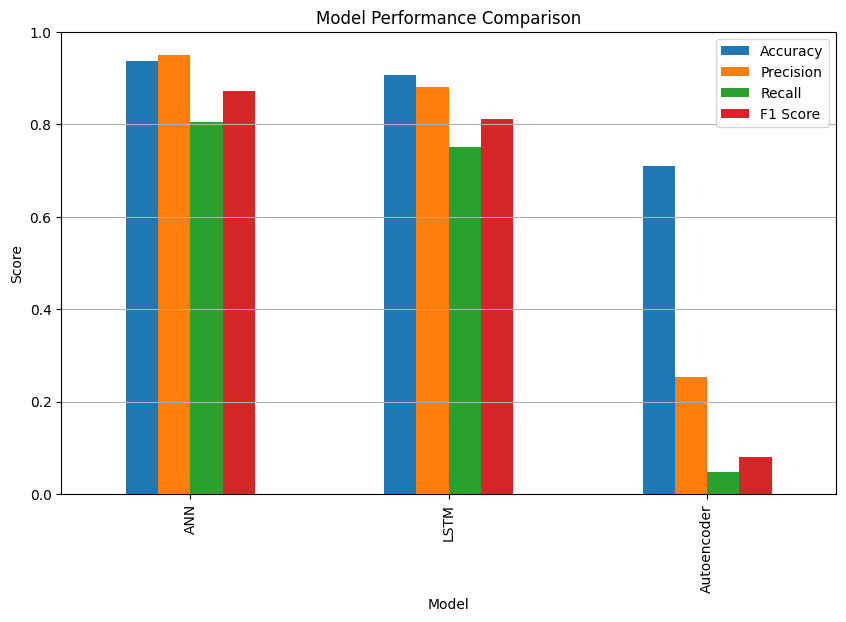

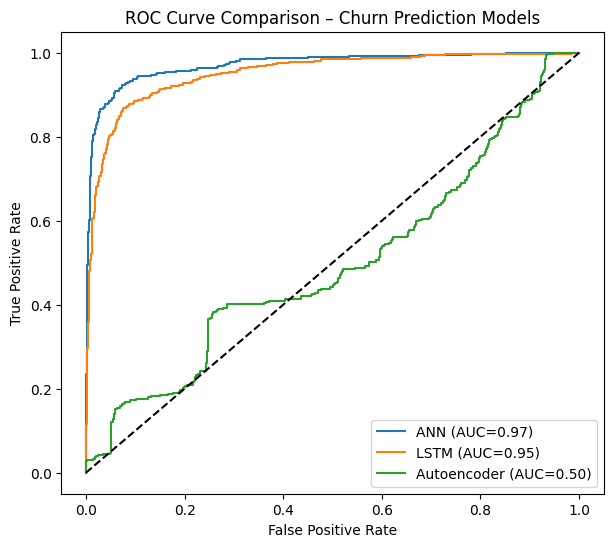

 Best Performing Model:
Model             ANN
Accuracy     0.936835
Precision    0.949527
Recall       0.804813
F1 Score     0.871201
Name: 0, dtype: object


In [9]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["ANN", "LSTM", "Autoencoder"],
    "Accuracy": [ann_accuracy, lstm_accuracy, ae_accuracy],
    "Precision": [ann_precision, lstm_precision, ae_precision],
    "Recall": [ann_recall, lstm_recall, ae_recall],
    "F1 Score": [ann_f1, lstm_f1, ae_f1]
})

results_df
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()
plt.figure(figsize=(7,6))


fpr_ann, tpr_ann, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC={auc(fpr_ann, tpr_ann):.2f})")


fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_prob_lstm)
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={auc(fpr_lstm, tpr_lstm):.2f})")


fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder (AUC={auc(fpr_ae, tpr_ae):.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – Churn Prediction Models")
plt.legend()
plt.show()
best_model = results_df.sort_values("F1 Score", ascending=False).iloc[0]
print(" Best Performing Model:")
print(best_model)



In [10]:


import pandas as pd
from IPython.display import display


required_vars = [
    'ann_accuracy', 'ann_precision', 'ann_recall', 'ann_f1',
    'lstm_accuracy', 'lstm_precision', 'lstm_recall', 'lstm_f1',
    'ae_accuracy', 'ae_precision', 'ae_recall', 'ae_f1'
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Missing metric variables: {missing}")

model_comparison = pd.DataFrame({
    "Model": ["ANN", "LSTM", "Autoencoder"],
    "Accuracy": [
        float(ann_accuracy),
        float(lstm_accuracy),
        float(ae_accuracy)
    ],
    "Precision": [
        float(ann_precision),
        float(lstm_precision),
        float(ae_precision)
    ],
    "Recall": [
        float(ann_recall),
        float(lstm_recall),
        float(ae_recall)
    ],
    "F1-Score": [
        float(ann_f1),
        float(lstm_f1),
        float(ae_f1)
    ]
})

print(" MODEL PERFORMANCE COMPARISON")
display(model_comparison)

best_model = model_comparison.loc[model_comparison["F1-Score"].idxmax()]

print("\n BEST MODEL (Based on F1-Score)")
print(best_model)

model_comparison.to_csv("model_comparison_table.csv", index=False)
print("\n Comparison table saved as model_comparison_table.csv")


 MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,ANN,0.936835,0.949527,0.804813,0.871201
1,LSTM,0.907026,0.880878,0.751337,0.810967
2,Autoencoder,0.709723,0.253521,0.048128,0.080899



 BEST MODEL (Based on F1-Score)
Model             ANN
Accuracy     0.936835
Precision    0.949527
Recall       0.804813
F1-Score     0.871201
Name: 0, dtype: object

 Comparison table saved as model_comparison_table.csv


### **SAVE MODELS & SCALER** ###

In [11]:
import os

save_path = "/content/drive/MyDrive/Internship Projects DS/Telecom Customer Churn Prediction Dataset/saved_models"

os.makedirs(save_path, exist_ok=True)

print("Save directory ready:", save_path)
ann_model.save(f"{save_path}/ann_churn_model.h5")
print("ANN model saved")
lstm_model.save(f"{save_path}/lstm_churn_model.h5")
print("LSTM model saved")
autoencoder.save(f"{save_path}/autoencoder_churn_model.h5")
print("Autoencoder model saved")
import joblib

joblib.dump(scaler, f"{save_path}/scaler.pkl")
print("Scaler saved")
results_df.to_csv(f"{save_path}/model_comparison_results.csv", index=False)
print("Model comparison results saved")




Save directory ready: /content/drive/MyDrive/Internship Projects DS/Telecom Customer Churn Prediction Dataset/saved_models


ANN model saved


LSTM model saved
Autoencoder model saved
Scaler saved
Model comparison results saved
